## Ejercicio 1: Evaluación de solicitud de crédito bancario
 
Aquí el agente recibe los datos de una solicitud de crédito y tiene que decidir solo, sin que
intervenga un asesor, si el préstamo se aprueba o no.
 
### Ficha PEAS
 
| | |
|---|---|
| **Percepción (S)** | El ingreso mensual del cliente, el monto que está pidiendo y si tiene o no historial moroso. Con los dos primeros datos el agente calcula la relación monto/ingreso, que es lo que realmente usa para decidir. |
| **Acciones (A)** | Aprobar, aprobar con condiciones (pedir garante o bajar el monto) o rechazar. |
| **Entorno (E)** | El área de créditos del banco: las solicitudes que van llegando, la base de datos donde está el historial de cada cliente y las políticas de riesgo que maneja la entidad. |
| **Objetivo** | Prestar plata a quien sí va a poder pagarla y no prestársela a quien no. |
| **Medida de desempeño (P)** | Cuántos créditos aprobados terminan pagándose sin atraso, cuánta morosidad acumula el banco y cuántos clientes buenos se rechazaron por gusto. |
 
**Tipo de agente:** es un agente reactivo simple. Funciona con reglas del tipo si-entonces y decide
solo con los datos de la solicitud que tiene al frente; no se acuerda de las solicitudes anteriores ni
aprende de ellas.
 
**¿Es racional?** Sí, siempre que los datos que recibe sean correctos. Si el ingreso llegara mal
registrado (por ejemplo un ingreso de 0 o negativo), el agente estaría decidiendo sobre un cliente que
no existe, así que la función revisa eso antes de calcular nada.
 

### Justificación de las reglas
 
Elegí la relación monto/ingreso porque es lo que de verdad mide si el cliente puede pagar: no es lo
mismo pedir S/ 2000 ganando S/ 4000 que pedir lo mismo ganando S/ 800. Mientras más sube esa
relación, más se le complica la cuota al cliente, por eso separé la decisión en tramos en vez de usar
un solo corte. El historial moroso lo tomé como agravante y le bajé los umbrales a la mitad, porque
alguien que ya dejó de pagar antes tiene más chance de volver a hacerlo. Dejé el tramo intermedio de
"aprobar con condiciones" para no perder clientes que sí sirven y solo necesitan un monto más bajo o
un plazo más largo, que al banco le conviene más que decirles que no.
 
**Reglas:**
 
| Historial moroso | Relación monto/ingreso | Decisión |
|---|---|---|
| No | hasta 1.0 | aprobar |
| No | entre 1.0 y 2.0 | aprobar con condiciones |
| No | más de 2.0 | rechazar |
| Sí | hasta 0.5 | aprobar con condiciones |
| Sí | más de 0.5 | rechazar |
 
Cuando la relación cae justo en el umbral (1.0, 2.0 o 0.5), se queda en el tramo menos estricto.
 

### Código
 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
 
 
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    # si el ingreso llega en 0 o negativo el dato esta mal y ademas no se puede dividir
    if ingreso_mensual <= 0:
        return "rechazar", "el ingreso reportado no es valido, no se puede evaluar"
 
    relacion = monto_solicitado / ingreso_mensual
    r = round(relacion, 2)
 
    # cliente con historial moroso: se le exige el doble
    if tiene_historial_moroso:
        if relacion <= 0.5:
            return "aprobar con condiciones", "relacion de " + str(r) + " es baja pero tiene historial moroso, se pide garante"
        else:
            return "rechazar", "relacion de " + str(r) + " mayor a 0.5 con historial moroso"
 
    # cliente sin historial moroso
    if relacion <= 1.0:
        return "aprobar", "relacion de " + str(r) + " menor o igual a 1.0 y sin historial moroso"
    elif relacion <= 2.0:
        return "aprobar con condiciones", "relacion de " + str(r) + " entre 1.0 y 2.0, conviene bajar el monto o alargar el plazo"
    else:
        return "rechazar", "relacion de " + str(r) + " mayor a 2.0, el monto es muy alto para su ingreso"

 
### Simulación y pruebas
 
Probé 7 combinaciones. La cuarta es el caso del borde exacto (relación igual a 1.0) y las dos últimas
son el borde de 0.5 para un cliente moroso: una cae justo en el umbral y la otra se pasa por un sol.
 

In [10]:
casos = [
    (3000, 1500, False),
    (2000, 3000, False),
    (1500, 6000, False),
    (2500, 2500, False),   # borde: relacion = 1.0
    (4000, 1000, True),
    (4000, 2000, True),    # borde: relacion = 0.5 con mora
    (4000, 2001, True),    # se pasa del borde por un sol
]
 
for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print("Ingreso:", ingreso, "| Monto:", monto, "| Moroso:", moroso,
          "| Relacion:", round(monto / ingreso, 3))
    print("   ->", accion, "(" + motivo + ")")
    print()
    

Ingreso: 3000 | Monto: 1500 | Moroso: False | Relacion: 0.5
   -> aprobar (relacion de 0.5 menor o igual a 1.0 y sin historial moroso)

Ingreso: 2000 | Monto: 3000 | Moroso: False | Relacion: 1.5
   -> aprobar con condiciones (relacion de 1.5 entre 1.0 y 2.0, conviene bajar el monto o alargar el plazo)

Ingreso: 1500 | Monto: 6000 | Moroso: False | Relacion: 4.0
   -> rechazar (relacion de 4.0 mayor a 2.0, el monto es muy alto para su ingreso)

Ingreso: 2500 | Monto: 2500 | Moroso: False | Relacion: 1.0
   -> aprobar (relacion de 1.0 menor o igual a 1.0 y sin historial moroso)

Ingreso: 4000 | Monto: 1000 | Moroso: True | Relacion: 0.25
   -> aprobar con condiciones (relacion de 0.25 es baja pero tiene historial moroso, se pide garante)

Ingreso: 4000 | Monto: 2000 | Moroso: True | Relacion: 0.5
   -> aprobar con condiciones (relacion de 0.5 es baja pero tiene historial moroso, se pide garante)

Ingreso: 4000 | Monto: 2001 | Moroso: True | Relacion: 0.5
   -> rechazar (relacion de 0.5 

 
### Visualización
 
Genero 200 solicitudes al azar con numpy, paso cada una por el agente y las grafico: en el eje X la
relación monto/ingreso y en el eje Y el ingreso mensual, con un color distinto por decisión.
 

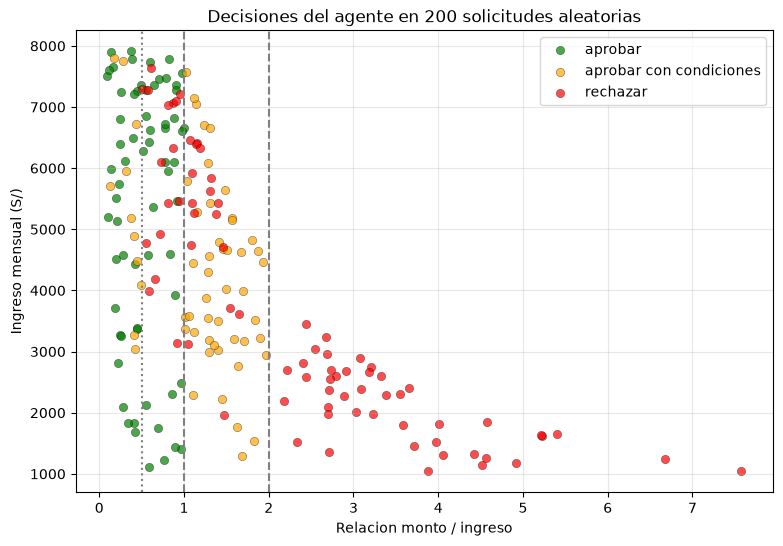

aprobar : 66 solicitudes
aprobar con condiciones : 57 solicitudes
rechazar : 77 solicitudes


In [11]:
np.random.seed(42)
n = 200
 
ingresos = np.random.uniform(1000, 8000, n)
montos = np.random.uniform(500, 9000, n)
morosos = np.random.rand(n) < 0.3          # aprox. 30% con historial moroso
 
relaciones = montos / ingresos
 
decisiones = []
for i in range(n):
    accion, motivo = agente_credito(ingresos[i], montos[i], morosos[i])
    decisiones.append(accion)
decisiones = np.array(decisiones)
 
colores = {"aprobar": "green", "aprobar con condiciones": "orange", "rechazar": "red"}
 
plt.figure(figsize=(9, 6))
for accion in colores:
    filtro = decisiones == accion
    plt.scatter(relaciones[filtro], ingresos[filtro], c=colores[accion],
                label=accion, alpha=0.7, edgecolors="black", linewidths=0.3)
 
plt.axvline(0.5, color="gray", linestyle=":")
plt.axvline(1.0, color="gray", linestyle="--")
plt.axvline(2.0, color="gray", linestyle="--")
 
plt.xlabel("Relacion monto / ingreso")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Decisiones del agente en 200 solicitudes aleatorias")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
 
# cuantas solicitudes cayeron en cada decision
for accion in colores:
    print(accion, ":", int((decisiones == accion).sum()), "solicitudes")
    


Lo que se nota en el gráfico es que los colores se separan en franjas verticales y no cambian nada
hacia arriba o hacia abajo. Eso tiene sentido, porque al agente no le importa cuánto gana el cliente
en términos absolutos sino la proporción entre lo que pide y lo que gana. También se ven puntos
rojos metidos en la zona verde: son los clientes con historial moroso, que se rechazan antes que
el resto.